<a href="https://colab.research.google.com/github/ZhanRomanov/Bakalaurs/blob/main/Bakalaurs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**3.2	Datu ģenerēšanas realizācija**

 Bibliotēku importēšana un vides sagatavošana

In [1]:
# 1. šūna: Vides sagatavošana, Google Drive pieslēgšana un bibliotēku importēšana

# Pieslēdzam Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import csv
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Fiksējam sēklas (seeds) eksperimentu atkārtojamībai
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ==========================================
# Direktoriju un failu sagatavošana Google Drive
# ==========================================
BASE_DIR = '/content/drive/MyDrive/Bakalaurs_Dati'

WEIGHTS_DIR = f"{BASE_DIR}/weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

CONFIGS_FILE = f"{BASE_DIR}/configs.csv"
METADATA_FILE = f"{BASE_DIR}/models_metadata.csv"

# ==========================================
# DROŠA FAILU IZVEIDE (Netīrīs jau esošos datus!)
# ==========================================
if not os.path.exists(CONFIGS_FILE):
    with open(CONFIGS_FILE, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['model_id', 'learning_rate', 'batch_size', 'optimizer', 'l2_reg', 'dropout', 'activation', 'epochs'])
        print("Izveidots jauns configs.csv fails.")
else:
    print("configs.csv jau eksistē. Dati tiks pievienoti klāt.")

if not os.path.exists(METADATA_FILE):
    with open(METADATA_FILE, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['model_id', 'test_accuracy', 'quality_class'])
        print("Izveidots jauns models_metadata.csv fails.")
else:
    print("models_metadata.csv jau eksistē. Dati tiks pievienoti klāt.")

print(f"Vide sagatavota! Strādājam direktorijā: {BASE_DIR}")

Mounted at /content/drive
configs.csv jau eksistē. Dati tiks pievienoti klāt.
models_metadata.csv jau eksistē. Dati tiks pievienoti klāt.
Vide sagatavota! Strādājam direktorijā: /content/drive/MyDrive/Bakalaurs_Dati


Hiperparametru ģenerēšana

In [2]:
def generate_hyperparameters():
    """Ģenerē nejaušu hiperparametru konfigurāciju."""
    learning_rate = 10 ** random.choice([-5,-4,-3,-2, -1])
    batch_size = random.choice([16, 32, 64, 128, 256, 512])
    optimizer_choice = random.choice(['sgd', 'adam'])
    l2_reg = random.choice([0, 1e-5, 1e-4, 1e-3])
    dropout_prob = random.choice([0, 0.2, 0.5])
    activation_fn = random.choice(['relu', 'sigmoid'])
    epochs = random.choice([5, 10, 20, 35, 50])

    return {
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'optimizer': optimizer_choice,
        'l2_reg': l2_reg,
        'dropout': dropout_prob,
        'activation': activation_fn,
        'epochs': epochs
    }

print("Hiperparametru ģenerēšanas funkcija gatava!")

Hiperparametru ģenerēšanas funkcija gatava!


Modeļa arhitektūra un apmācības loģika

In [3]:
class MLP_MNIST(nn.Module):
    def __init__(self, activation_fn_name, dropout_prob):
        super(MLP_MNIST, self).__init__()

        # Slāņu definīcijas
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        # Aktivācijas funkcija
        if activation_fn_name == 'relu':
            self.activation = nn.ReLU()
        else:
            self.activation = nn.Sigmoid()

        # Dropout slānis
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten attēlu 28x28 uz 784

        x = self.fc1(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x

def train_model(model, train_loader, optimizer, criterion, epochs, device):
    model.train()
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    return 100 * correct / total

print("Modeļa klase un apmācības/novērtēšanas funkcijas gatavas!")

Modeļa klase un apmācības/novērtēšanas funkcijas gatavas!


Datu ģenerēšana un svaru saglabāšana

In [ ]:
# -----------------------------------------------------------------
# 4. šūna: Galvenais ģenerēšanas cikls ar atsākšanas (resume) funkciju
# -----------------------------------------------------------------

# Ierīces iestatīšana
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Izmanto ierīci: {device}")

# Datu transformācijas
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Pilnās MNIST datu kopas ielāde
print("Ielādē MNIST datus...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

NUM_MODELS = 500

# =================================================================
# 1. Pārbaudām pēdējo saglabāto modeli 'weights' mapē
# =================================================================
last_model_id = 0
if os.path.exists(WEIGHTS_DIR):
    # Atrodam visus failus, kas beidzas ar .npy
    npy_files = [f for f in os.listdir(WEIGHTS_DIR) if f.startswith('model_') and f.endswith('.npy')]

    if npy_files:
        # Izvelkam numurus, piemēram, no "model_0043_layer1.npy" dabūjam 43
        model_numbers = [int(f.split('_')[1]) for f in npy_files]
        last_model_id = max(model_numbers)

print(f"\n--- 'weights' mapē atklāti {last_model_id} modeļi. Turpinām no {last_model_id + 1}. modeļa ---")

start_index = last_model_id # Pielāgojam indeksu ciklam

# =================================================================
# 2. Sēklu atiestatīšana un "pārtīšana"
# =================================================================
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Tukšgaitā izsaucam ģenerēšanu iepriekšējiem modeļiem, lai
# random stāvoklis nonāktu tieši tur, kur tam jābūt!
for _ in range(start_index):
    _ = generate_hyperparameters()

# =================================================================
# 3. Galvenais ģenerēšanas cikls (sākas no start_index)
# =================================================================
for i in range(start_index, NUM_MODELS):
    model_id = f"model_{i+1:04d}"
    params = generate_hyperparameters()

    print(f"[{i+1}/{NUM_MODELS}] Ģenerē {model_id} ar parametriem: {params}")

    # Datu lādētāji konkrētajam modelim
    train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=params['batch_size'], shuffle=False)

    # Modeļa iniciēšana
    model = MLP_MNIST(params['activation'], params['dropout']).to(device)

    # Zaudējuma funkcija
    criterion = nn.CrossEntropyLoss()

    # Optimizatora izvēle
    if params['optimizer'] == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=params['learning_rate'],
                              momentum=0.9, weight_decay=params['l2_reg'])
    else:
        optimizer = optim.Adam(model.parameters(), lr=params['learning_rate'],
                               weight_decay=params['l2_reg'])

    # Apmācība
    train_model(model, train_loader, optimizer, criterion, params['epochs'], device)

    # Novērtēšana
    test_acc = evaluate_model(model, test_loader, device)

    # Kvalitātes marķēšana
    if test_acc >= 95.0:
        quality_class = "labs"
    elif test_acc >= 80.0:
        quality_class = "vidējs"
    else:
        quality_class = "slikts"

    print(f"--> {model_id} pabeigts. Precizitāte: {test_acc:.2f}% | Klase: {quality_class}\n")

    # Svaru saglabāšana
    state_dict = model.state_dict()
    np.save(os.path.join(WEIGHTS_DIR, f"{model_id}_layer1.npy"), state_dict['fc1.weight'].cpu().numpy())
    np.save(os.path.join(WEIGHTS_DIR, f"{model_id}_layer2.npy"), state_dict['fc2.weight'].cpu().numpy())
    np.save(os.path.join(WEIGHTS_DIR, f"{model_id}_layer3.npy"), state_dict['fc3.weight'].cpu().numpy())

    # Konfigurācijas saglabāšana CSV
    with open(CONFIGS_FILE, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            model_id, params['learning_rate'], params['batch_size'],
            params['optimizer'], params['l2_reg'], params['dropout'],
            params['activation'], params['epochs']
        ])

    # Metadatu saglabāšana CSV
    with open(METADATA_FILE, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([model_id, test_acc, quality_class])

print("Visi modeļi veiksmīgi ģenerēti un saglabāti!")

Statistisko pazīmju izguves

In [8]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# Bāzes direktorijas
BASE_DIR = '/content/drive/MyDrive/Bakalaurs_Dati'
WEIGHTS_DIR = f"{BASE_DIR}/weights"
METADATA_FILE = f"{BASE_DIR}/models_metadata.csv"
FEATURES_FILE = f"{BASE_DIR}/extracted_features.csv"

print("Sāku pazīmju izguvi...")

# 1. Ielādējam metadatus, lai dabūtu kvalitātes klasi katram modelim
df_meta = pd.read_csv(METADATA_FILE)
# Izveidojam vārdnīcu ātrai meklēšanai: {'model_0001': 'vidējs', ...}
quality_map = dict(zip(df_meta['model_id'], df_meta['quality_class']))

features_list = []

# 2. Iterējam cauri visiem 500 modeļiem
for i in range(1, 501):
    model_id = f"model_{i:04d}"

    # Svaru failu ceļi
    path_l1 = os.path.join(WEIGHTS_DIR, f"{model_id}_layer1.npy")
    path_l2 = os.path.join(WEIGHTS_DIR, f"{model_id}_layer2.npy")
    path_l3 = os.path.join(WEIGHTS_DIR, f"{model_id}_layer3.npy")

    # Drošības pārbaude (lai izlaistu, ja kāda iemesla dēļ fails neeksistē)
    if not (os.path.exists(path_l1) and os.path.exists(path_l2) and os.path.exists(path_l3)):
        print(f"KĻŪDA: Trūkst failu modelim {model_id}!")
        continue

    # Ielādējam un uzreiz "saplacinām" (flatten) matricas 1D masīvā statistikai
    w1 = np.load(path_l1).flatten()
    w2 = np.load(path_l2).flatten()
    w3 = np.load(path_l3).flatten()

    # Izveidojam bāzes vārdnīcu šim modelim
    model_features = {'model_id': model_id}

    # 3. Aprēķinām 6 pazīmes katram no 3 slāņiem
    for layer_idx, w in enumerate([w1, w2, w3], start=1):
        model_features[f'l{layer_idx}_mean'] = np.mean(w)
        model_features[f'l{layer_idx}_var'] = np.var(w)
        model_features[f'l{layer_idx}_skew'] = skew(w)
        model_features[f'l{layer_idx}_kurtosis'] = kurtosis(w)
        model_features[f'l{layer_idx}_l2_norm'] = np.linalg.norm(w)
        model_features[f'l{layer_idx}_max_amp'] = np.max(np.abs(w))

    # 4. Pievienojam mērķa mainīgo (quality_class)
    model_features['quality_class'] = quality_map.get(model_id, 'nezināms')

    features_list.append(model_features)

# 5. Konvertējam uz Pandas DataFrame un saglabājam
df_features = pd.DataFrame(features_list)
df_features.to_csv(FEATURES_FILE, index=False)

print(f"Pazīmju inženierija pabeigta! Dati saglabāti failā: {FEATURES_FILE}")
print(f"Iegūtas {df_features.shape[1] - 2} pazīmes {df_features.shape[0]} modeļiem.")

Sāku pazīmju izguvi...
Pazīmju inženierija pabeigta! Dati saglabāti failā: /content/drive/MyDrive/Bakalaurs_Dati/extracted_features.csv
Iegūtas 18 pazīmes 500 modeļiem.


Diagnostikas klasifikatora realizācija

Ielādēju datus...
Apmācības kopa: 400 modeļi
Testa kopa: 100 modeļi

Sāku modeļa apmācību un hiperparametru optimizāciju (GridSearchCV)...
Labākie parametri: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

=== REZULTĀTI UZ TESTA KOPAS ===
Kopējā precizitāte (Accuracy): 86.00%

Klasifikācijas atskaite:
              precision    recall  f1-score   support

        labs       0.80      0.97      0.88        33
      slikts       0.94      0.92      0.93        36
      vidējs       0.84      0.68      0.75        31

    accuracy                           0.86       100
   macro avg       0.86      0.85      0.85       100
weighted avg       0.86      0.86      0.86       100



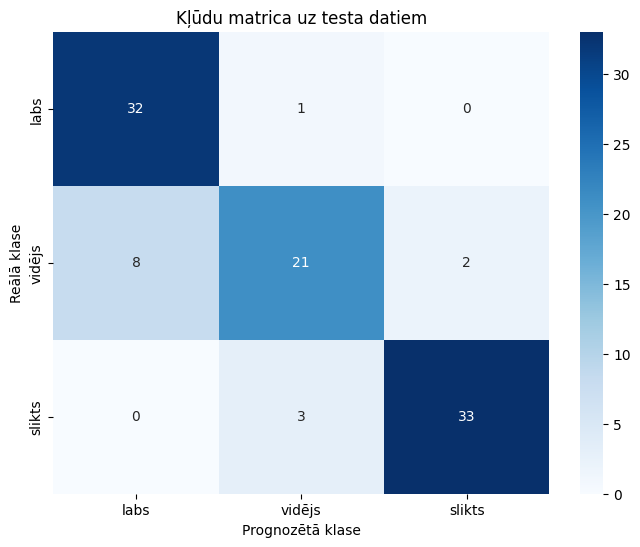

/tmp/ipykernel_3257/2858170179.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


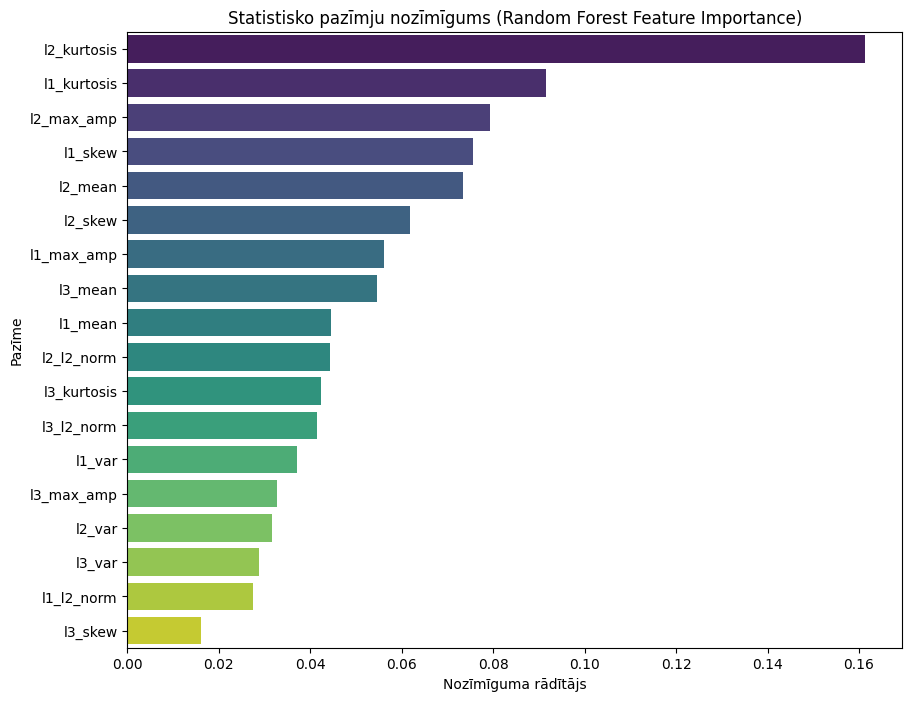

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Datu ielāde
BASE_DIR = '/content/drive/MyDrive/Bakalaurs_Dati'
FEATURES_FILE = f"{BASE_DIR}/extracted_features.csv"

print("Ielādēju datus...")
df = pd.read_csv(FEATURES_FILE)

# Atdalām pazīmes (X) no mērķa mainīgā (y)
# Izmetam 'model_id', jo tas nav statistisks rādītājs
X = df.drop(columns=['model_id', 'quality_class'])
y = df['quality_class']

# 2. Datu sadale apmācības un testa kopās (80% / 20%)
# stratify=y nodrošina, ka klašu proporcijas abās kopās saglabājas vienādas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Apmācības kopa: {X_train.shape[0]} modeļi")
print(f"Testa kopa: {X_test.shape[0]} modeļi\n")

# 3. Random Forest modeļa inicializācija un hiperparametru režģa meklēšana (Grid Search)
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],      # Koku skaits mežā
    'max_depth': [None, 10, 20, 30],     # Koku maksimālais dziļums
    'min_samples_split': [2, 5, 10]      # Minimālais paraugu skaits, lai sadalītu zaru
}

print("Sāku modeļa apmācību un hiperparametru optimizāciju (GridSearchCV)...")
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Labākie parametri: {grid_search.best_params_}\n")

# 4. Modeļa novērtēšana uz testa datiem
y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"=== REZULTĀTI UZ TESTA KOPAS ===")
print(f"Kopējā precizitāte (Accuracy): {accuracy * 100:.2f}%\n")
print("Klasifikācijas atskaite:")
print(classification_report(y_test, y_pred))

# 5. Vizualizācija: Kļūdu matrica (Confusion Matrix)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=['labs', 'vidējs', 'slikts'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['labs', 'vidējs', 'slikts'],
            yticklabels=['labs', 'vidējs', 'slikts'])
plt.title("Kļūdu matrica uz testa datiem")
plt.xlabel("Prognozētā klase")
plt.ylabel("Reālā klase")
plt.show()

# 6. Vizualizācija: Pazīmju nozīmīgums (Feature Importance)
importances = best_rf.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title("Statistisko pazīmju nozīmīgums (Random Forest Feature Importance)")
plt.xlabel("Nozīmīguma rādītājs")
plt.ylabel("Pazīme")
plt.show()